In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import Functional_Fusion.atlas_map as am
from HierarchBayesParcel.evaluation import calc_test_error
import HierarchBayesParcel.arrangements as ar
import nitools as nt
from IndividualParcellation.global_config import *


In [2]:
atlas,_= am.get_atlas(atlas_str='MNISymC2')
dist = compute_dist(atlas.world.T, resolution=1)


In [3]:
# Load group prior
model_name = f'/Atlases/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32_space-MNI152NLin2009cSymC_probseg.nii'
_, cmap, labels = nt.read_lut(f'{BASE_DIR}/Atlases/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32.lut')
U = atlas.read_data(BASE_DIR + model_name)
U = U.T
sym_type = 'sym'

# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(U, prior_type='prob', atlas=atlas,
                                        sym_type='sym')

C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\arrangements.py:1879: UserWarning: The marginal probability has 18207 voxels zero values - adding small value to avoid -inf
  warnings.warn(f'The marginal probability has {zero_voxl} voxels'


# MDTB Vs

In [4]:
# mdtb vs based on HBP
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models'
if not os.path.exists(model_dir):
    model_dir = '/cifs/diedrichsen/data/Cerebellum/ProbabilisticParcellationModel/Models'
    
model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
fname = model_dir + model_name
with open(fname + '.pickle', 'rb') as file:
        full_model = pickle.load(file)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

In [5]:
cond_vec = np.tile(np.arange(1, 8 + 1), 1)
part_vec = np.repeat(np.arange(1, 1 + 1), 8)

In [6]:
def HBP_u(train_data,cond_vec,part_vec):
    x_matrix = indicator(cond_vec)
    
    
    em_model = em.MixVMF(K=32, P=18290, X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([train_data])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

    return U_data

In [7]:
def evaluate_cos(D,ytrain,Vs,ytest,vtest,M):
    for i, row in D.iterrows():
        print(i)
        task_subset_indices = row['combination']
        V_subset = Vs[task_subset_indices, :]
        
        # Subtract mean across rows
        V_subset = V_subset - np.mean(V_subset, axis=0)
        
        # Generate the data Y from U_true and V_subset
        y_subset = ytrain[:,task_subset_indices, :]

        # Estimate U_hat using OLS
        # U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        # U_hat_NNLS = sim.estimate_Us_NNLS(y_subset, V_subset)    

        # make into tensores
        ytest = pt.tensor(ytest,dtype=pt.float32)
        vtest = pt.tensor(vtest,dtype=pt.float32)
        # U_hat_ols = pt.tensor(U_hat_ols,dtype=pt.float32)
        # U_hat_NNLS = pt.tensor(U_hat_NNLS,dtype=pt.float32)
        U_hat_HBP = [HBP_u(y_subset,cond_vec,part_vec)]
        

        # cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().numpy()
        # cos_NNLS = ev.coserr(ytest,vtest,U_hat_NNLS).mean().numpy()
        cos_HBP = calc_test_error(M=M,tdata=ytest,U_hats=U_hat_HBP,fit_emission='use_Uhats').mean()
        

        # Pindiv = pt.argmax(U_hat_HBP, dim=1) + 1
        # dcbc_indiv = calc_test_dcbc(Pindiv, ytest, dist)

        # D.at[i, 'cos_ols'] = cos_ols
        # D.at[i, 'cos_NNLS'] = cos_NNLS
        D.at[i, 'cos_HBP'] = cos_HBP

    return D

In [14]:
def evaluate_cos(D, ytrain, Vs, ytest, vtest, M):
    # Create a new column with combinations as tuples to make them hashable
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    
    # Get unique combinations
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    cos_HBP_dict = {}
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)
        V_subset = Vs[task_subset_indices, :]
        V_subset = V_subset - np.mean(V_subset, axis=0)
        y_subset = ytrain[:, task_subset_indices, :]
        
        # Estimate U_hat using HBP_u
        U_hat_HBP = [HBP_u(y_subset, cond_vec, part_vec)]
        
        # Convert test data to tensors
        ytest_tensor = pt.tensor(ytest, dtype=pt.float32)
        vtest_tensor = pt.tensor(vtest, dtype=pt.float32)
        
        # Compute cos_HBP
        cos_HBP = calc_test_error(M=M, tdata=ytest_tensor, U_hats=U_hat_HBP, fit_emission='use_Uhats').mean()
        
        # Store the result in the dictionary
        cos_HBP_dict[comb_tuple] = cos_HBP
    
    # Map the computed cos_HBP values back to the DataFrame
    D['cos_HBP'] = D['combination_tuple'].map(cos_HBP_dict)
    
    return D


In [8]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')
data_mdtb_s1_All,info_mdtb_1_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s1',type='CondAll')
data_mdtb_s1_All[np.isnan(data_mdtb_s1_All)] = 0

In [9]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')
data_mdtb_s2_All,info_mdtb_2_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_All[np.isnan(data_mdtb_s2_All)] = 0

In [10]:
cond_vec_test = np.tile(np.arange(1, 32 + 1), 1)
part_vec_test = np.repeat(np.arange(1, 1 + 1), 32)
data_test = data_mdtb_s2_All


x_matrix = indicator(cond_vec_test)


em_model = em.MixVMF(K=32, P=18290, X=x_matrix, part_vec=part_vec_test,
                    subject_specific_kappa=False, parcel_specific_kappa=False, 
                    subjects_equal_weight=True)

M_2 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
M_2.initialize([data_test])

M_2, ll,_,U_individual = M_2.fit_em(iter=200, tol=0.01,
                                fit_arrangement=False,
                                fit_emission= True,
                                first_evidence=False)    


Likelihood decreased - terminating on iteration 90


In [17]:
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',n_iter=1000,n_tasks=8,seed=53)
D_mdtb = evaluate_cos(D_mdtb, data_mdtb_s1_All,VL_mdtb, data_mdtb_s2_All, VL_mdtb_2,M_2)



Processing combination: 0
Likelihood decreased - terminating on iteration 90
Subject:0:0.0140s
Subject:1:0.0115s
Subject:2:0.0115s
Subject:3:0.0136s
Subject:4:0.0115s
Subject:5:0.0133s
Subject:6:0.0134s
Subject:7:0.0134s
Subject:8:0.0130s
Subject:9:0.0142s
Subject:10:0.0113s
Subject:11:0.0141s
Subject:12:0.0128s
Subject:13:0.0119s
Subject:14:0.0120s
Subject:15:0.0107s
Subject:16:0.0118s
Subject:17:0.0124s
Subject:18:0.0114s
Subject:19:0.0127s
Subject:20:0.0122s
Subject:21:0.0117s
Subject:22:0.0113s
Subject:23:0.0124s
Processing combination: 1
Subject:0:0.0134s
Subject:1:0.0119s
Subject:2:0.0139s
Subject:3:0.0131s
Subject:4:0.0131s
Subject:5:0.0131s
Subject:6:0.0109s
Subject:7:0.0128s
Subject:8:0.0140s
Subject:9:0.0108s
Subject:10:0.0113s
Subject:11:0.0120s
Subject:12:0.0116s
Subject:13:0.0124s
Subject:14:0.0119s
Subject:15:0.0124s
Subject:16:0.0128s
Subject:17:0.0112s
Subject:18:0.0128s
Subject:19:0.0119s
Subject:20:0.0113s
Subject:21:0.0125s
Subject:22:0.0123s
Subject:23:0.0115s
Proce

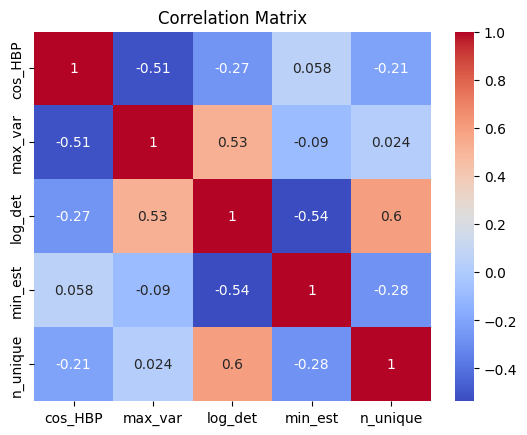

In [20]:
# Correlation heatmap
corr_matrix = D_mdtb[['cos_HBP','max_var', 'log_det', 'min_est','n_unique']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

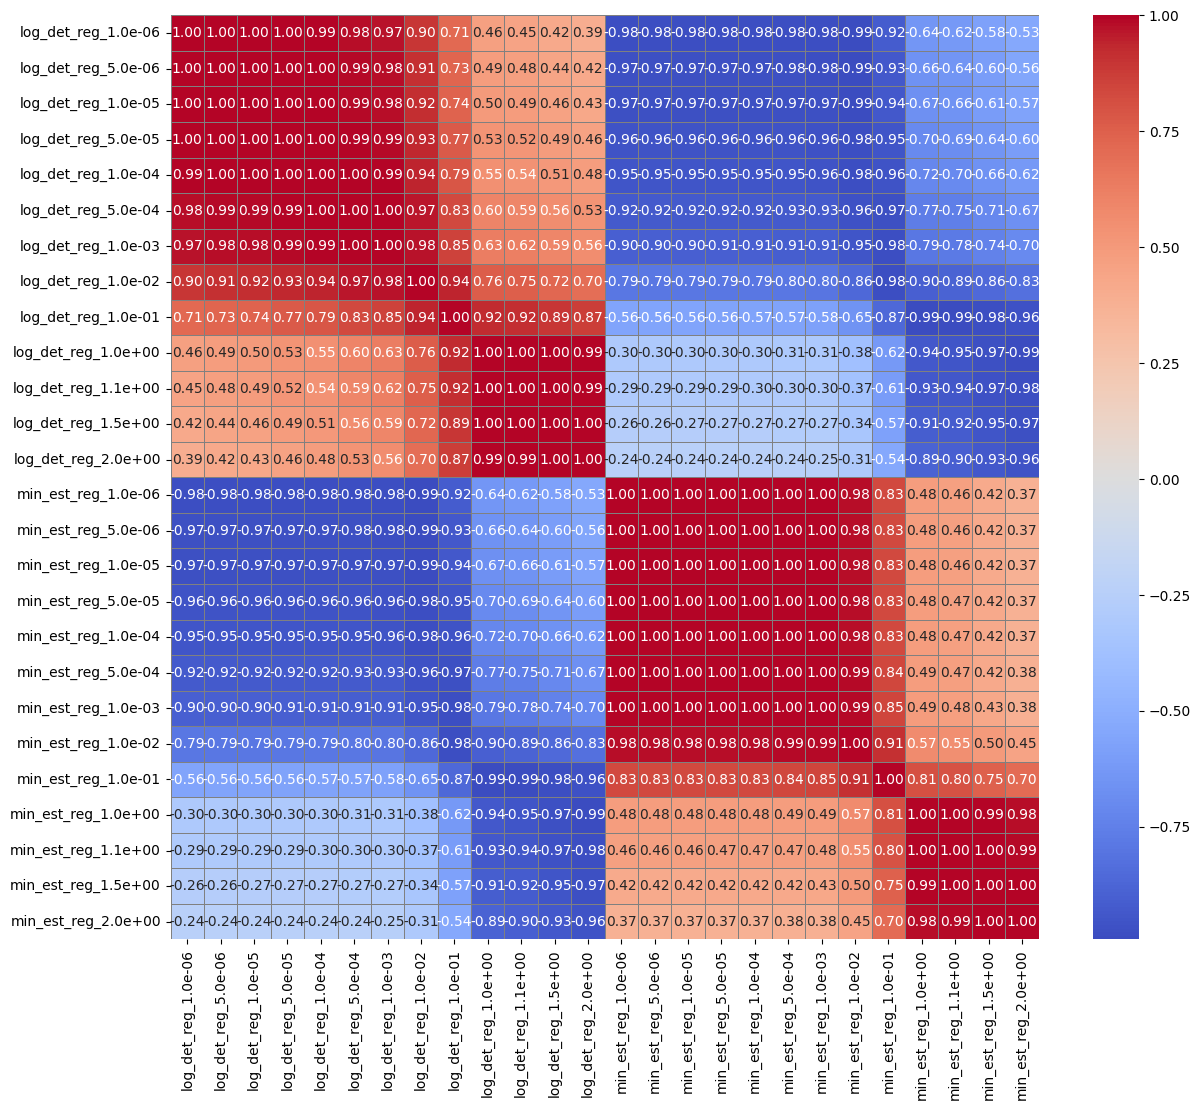

In [18]:
offsets = D_mdtb['offset'].unique()
correlation_matrix = np.zeros((len(offsets)*2, len(offsets)*2))

# Loop through all combinations of offsets
for i, offset_1 in enumerate(offsets):
    for j, offset_2 in enumerate(offsets):
        # Subset for log_det and min_est with offset_1
        subset_1 = D_mdtb[D_mdtb['offset'] == offset_1]
        log_det_values_1 = subset_1['log_det'].values
        min_est_values_1 = subset_1['min_est'].values

        # Subset for log_det and min_est with offset_2
        subset_2 = D_mdtb[D_mdtb['offset'] == offset_2]
        log_det_values_2 = subset_2['log_det'].values
        min_est_values_2 = subset_2['min_est'].values

        # Calculate correlation between log_det from offset_1 and log_det from offset_2
        log_det_corr = np.corrcoef(log_det_values_1, log_det_values_2)[0, 1]

        # Calculate correlation between min_est from offset_1 and min_est from offset_2
        min_est_corr = np.corrcoef(min_est_values_1, min_est_values_2)[0, 1]

        # Calculate correlation between log_det from offset_1 and min_est from offset_2
        log_det_min_est_corr = np.corrcoef(log_det_values_1, min_est_values_2)[0, 1]

        # Fill in the 20x20 correlation matrix
        correlation_matrix[i, j] = log_det_corr                      # log_det vs log_det
        correlation_matrix[i + len(offsets), j + len(offsets)] = min_est_corr            # min_est vs min_est
        correlation_matrix[i, j + len(offsets)] = log_det_min_est_corr         # log_det vs min_est
        correlation_matrix[i + len(offsets), j] = log_det_min_est_corr         # min_est vs log_det (same value)

# labels
log_det_labels = [f'log_det_reg_{offset:.1e}' for offset in offsets]  # e.g., log_det_reg_1e-06
min_est_labels = [f'min_est_reg_{offset:.1e}' for offset in offsets]  # e.g., min_est_reg_1e-06
x_labels = log_det_labels + min_est_labels
y_labels = log_det_labels + min_est_labels

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, linecolor='gray',
            xticklabels=x_labels, yticklabels=y_labels)
plt.xticks(rotation=90) 
plt.show()


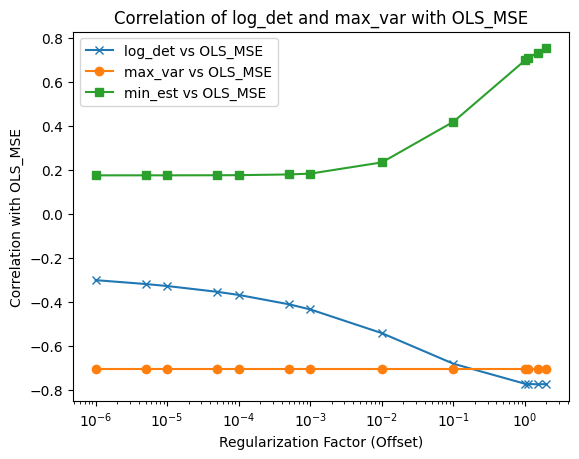

In [19]:

offsets = D_mdtb['offset'].unique()
log_det_corrs = []
max_var_corrs = []
min_est_corrs = []

for offset in offsets:
    subset = D_mdtb[D_mdtb['offset'] == offset]
    
    log_det_corr = np.corrcoef(subset['log_det'], subset['cos_HBP'])[0, 1]
    log_det_corrs.append(log_det_corr)
    
    max_var_corr = np.corrcoef(subset['max_var'], subset['cos_HBP'])[0, 1]
    max_var_corrs.append(max_var_corr)

    min_est_corr = np.corrcoef(subset['min_est'], subset['cos_HBP'])[0, 1]
    min_est_corrs.append(min_est_corr)


plt.plot(offsets, log_det_corrs, label='log_det vs OLS_MSE', marker='x')
plt.plot(offsets, max_var_corrs, label='max_var vs OLS_MSE', marker='o')
plt.plot(offsets, min_est_corrs, label='min_est vs OLS_MSE', marker='s')

plt.xscale('log')  
plt.xlabel('Regularization Factor (Offset)')
plt.ylabel('Correlation with OLS_MSE')
plt.title('Correlation of log_det and max_var with OLS_MSE')
plt.legend()
plt.show()

In [26]:
# print correlations at offset = 1 (best offset)
best_offset = 1
subset = D_mdtb[D_mdtb['offset'] == best_offset]
log_det_corr = np.corrcoef(subset['log_det'], subset['cos_HBP'])[0, 1]
max_var_corr = np.corrcoef(subset['max_var'], subset['cos_HBP'])[0, 1]
min_est_corr = np.corrcoef(subset['min_est'], subset['cos_HBP'])[0, 1]

print(f'log_det vs cos_HBP correlation at offset = {best_offset}: {log_det_corr}')
print(f'max_var vs cos_HBP correlation at offset = {best_offset}: {max_var_corr}')
print(f'min_est vs cos_HBP correlation at offset = {best_offset}: {min_est_corr}')

# print siginificance for correlation at offset = 1 (best offset)
log_det_pval = pearsonr(subset['log_det'], subset['cos_HBP'])[1]
max_var_pval = pearsonr(subset['max_var'], subset['cos_HBP'])[1]
min_est_pval = pearsonr(subset['min_est'], subset['cos_HBP'])[1]


log_det vs cos_HBP correlation at offset = 1: -0.7711709854628291
max_var vs cos_HBP correlation at offset = 1: -0.7033315221286466
min_est vs cos_HBP correlation at offset = 1: 0.6988245922662374
